<a href="https://colab.research.google.com/github/Mru321/CSI-Cross-Environment-Generalization/blob/main/CNN%20%2B%20Transformer%20Model_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    ReLU,
    Dropout,
    Dense,
    GlobalAveragePooling1D,
    GlobalMaxPooling1D,
    Concatenate,
    MultiHeadAttention,
    LayerNormalization,
    Add
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

RAW_DIR = "/content/drive/MyDrive/Project/Project1/raw_data/renew_dataset/tvt_open_source/raw_traces"
PROCESSED_DIR = "/content/drive/MyDrive/Project/Project1/processed"

In [ ]:
import os
import numpy as np

files = sorted([f for f in os.listdir(PROCESSED_DIR) if f.endswith(".npy")])

file_info = []

for f in files:
    path = os.path.join(PROCESSED_DIR, f)

    label = 0 if "NLOS" in f else 1

    # FIXED env extraction
    env = f.replace(".npy", "")

    file_info.append((path, label, env))

In [ ]:
train_envs = [
    "channe14_LOS_cluster1",
    "channe14_LOS_cluster2",
    "channe14_NLOS_cluster1",
    "channe14_NLOS_cluster2",
    "channe14_NLOS_cluster3"
]

test_envs = [
    "channe14_LOS_cluster3",
    "channe14_LOS_cluster4",
    "channe14_NLOS_cluster4",
    "channe14_NLOS_cluster5"
]

In [ ]:
X_train_list = []
y_train_list = []

X_test_list = []
y_test_list = []

for path, label, env in file_info:

    data = np.load(path)

    # TRAIN
    if env in train_envs:

        X_train_list.append(data)

        y_train_list.append(
            np.full((data.shape[0],), label)
        )

    # TEST
    elif env in test_envs:

        X_test_list.append(data)

        y_test_list.append(
            np.full((data.shape[0],), label)
        )

In [ ]:
X_train = np.vstack(X_train_list)
y_train = np.hstack(y_train_list)

X_test = np.vstack(X_test_list)
y_test = np.hstack(y_test_list)

In [ ]:
X_train = X_train.reshape(X_train.shape[0], 72, 1)
X_test = X_test.reshape(X_test.shape[0], 72, 1)

In [ ]:
# TRANSFORMER ENCODER

def transformer_encoder(
    inputs,
    head_size=32,
    num_heads=2,
    ff_dim=64,
    dropout=0.1
):

    # MULTI HEAD SELF ATTENTION

    attention = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    attention = Dropout(dropout)(attention)

    attention = Add()([inputs, attention])

    attention = LayerNormalization(
        epsilon=1e-6
    )(attention)

    # FEED FORWARD NETWORK

    ff = Dense(
        ff_dim,
        activation='relu'
    )(attention)

    ff = Dropout(dropout)(ff)

    ff = Dense(
        inputs.shape[-1]
    )(ff)

    ff = Add()([attention, ff])

    output = LayerNormalization(
        epsilon=1e-6
    )(ff)

    return output

In [ ]:
# CNN + TRANSFORMER MODEL

def build_cnn_transformer():

    # INPUT

    inputs = Input(shape=(72,1))

    # CNN BLOCK 1

    x = Conv1D(
        filters=64,
        kernel_size=3,
        padding='same'
    )(inputs)

    x = BatchNormalization()(x)

    x = ReLU()(x)

    # CNN BLOCK 2

    x = Conv1D(
        filters=128,
        kernel_size=3,
        padding='same'
    )(x)

    x = BatchNormalization()(x)

    x = ReLU()(x)

    x = Dropout(0.2)(x)

    # SINGLE TRANSFORMER BLOCK

    x = transformer_encoder(
        x,
        head_size=32,
        num_heads=2,
        ff_dim=64,
        dropout=0.1
    )

    # GLOBAL POOLING

    x = GlobalAveragePooling1D()(x)

    # DENSE LAYERS

    x = Dense(
        128,
        activation='relu'
    )(x)

    x = Dropout(0.3)(x)

    x = Dense(
        64,
        activation='relu'
    )(x)

    x = Dropout(0.2)(x)

    # OUTPUT

    outputs = Dense(
        1,
        activation='sigmoid'
    )(x)

    # MODEL

    model = Model(
        inputs,
        outputs
    )

    return model

In [ ]:
# CREATE MODEL

model = build_cnn_transformer()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 72, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 72, 64)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 72, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 72, 64)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 72, 128)   │     24,704 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 72, 128)   │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 72, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 72, 128)   │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 72, 128)   │     33,088 │ dropout[0][0],    │
│ (MultiHeadAttentio… │                   │            │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 72, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 72, 128)   │          0 │ dropout[0][0],    │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 72, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 72, 64)    │      8,256 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 72, 64)    │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 72, 128)   │      8,320 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 72, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 72, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 100,737 (393.50 KB)

 Trainable params: 100,353 (392.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
# COMPILE MODEL

model.compile(

    optimizer=Adam(
        learning_rate=0.00005
    ),

    loss='binary_crossentropy',

    metrics=['accuracy']
)

In [ ]:
# MILD CLASS WEIGHTS

class_weights = {
    0: 1.02,
    1: 1.0
}

print(class_weights)

{0: 1.02, 1: 1.0}


In [ ]:
# CALLBACKS

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
# TRAIN MODEL

history = model.fit(

    X_train,
    y_train,

    validation_data=(
        X_test,
        y_test
    ),

    epochs=20,

    batch_size=128,

    shuffle=True,

    class_weight=class_weights,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],

    verbose=1
)

Epoch 1/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.7274 - loss: 0.5494
Epoch 1: val_accuracy improved from None to 0.71820, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 92s 359ms/step - accuracy: 0.8483 - loss: 0.3966 - val_accuracy: 0.7182 - val_loss: 0.9859 - learning_rate: 5.0000e-05
Epoch 2/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.9683 - loss: 0.1148
Epoch 2: val_accuracy improved from 0.71820 to 0.86590, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 92s 385ms/step - accuracy: 0.9786 - loss: 0.0779 - val_accuracy: 0.8659 - val_loss: 0.4517 - learning_rate: 5.0000e-05
Epoch 3/20
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.9946 - loss: 0.0186
Epoch 3: val_accuracy did not improve from 0.86590
239/239 ━━━━━━━━━━━━━━━━━━━━ 92s 384ms/step - accuracy: 0.9957 - loss: 0.0155 - val_accuracy: 0.7397 - val_los

In [ ]:
# LOAD BEST SAVED MODEL

from tensorflow.keras.models import load_model

best_model = load_model(
    "best_model.keras"
)

In [ ]:
# EVALUATE BEST MODEL

loss, accuracy = best_model.evaluate(
    X_test,
    y_test
)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

761/761 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8659 - loss: 0.4517
Test Loss : 0.4517078101634979
Test Accuracy : 0.8659022450447083


In [ ]:
# PREDICTIONS

predictions = best_model.predict(
    X_test
)

predicted_labels = (
    predictions > 0.5
).astype(int)

761/761 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step


In [ ]:
# CONFUSION MATRIX + REPORT

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(
    y_test,
    predicted_labels
)

print(cm)

print(
    classification_report(
        y_test,
        predicted_labels
    )
)

[[ 5739  2381]
 [  882 15331]]
              precision    recall  f1-score   support

           0       0.87      0.71      0.78      8120
           1       0.87      0.95      0.90     16213

    accuracy                           0.87     24333
   macro avg       0.87      0.83      0.84     24333
weighted avg       0.87      0.87      0.86     24333



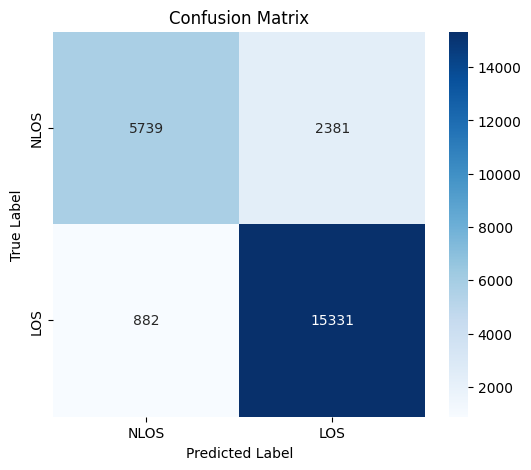

In [ ]:
# PLOT CONFUSION MATRIX

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['NLOS','LOS'],
    yticklabels=['NLOS','LOS']
)

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()

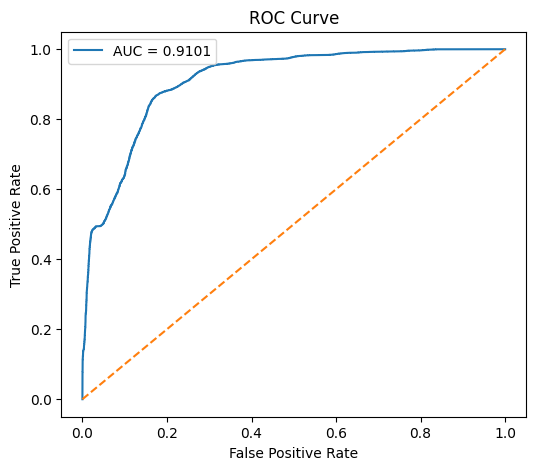

AUC Score : 0.9100610210926646


In [ ]:
# ROC CURVE

from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, thresholds = roc_curve(
    y_test,
    predictions
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.4f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("AUC Score :", roc_auc)